# Paired-Chain 10x VDJ Analysis Across 4 Donors

This notebook loads 10x_vdj_v1 donor data from the AIRR benchmark `dcode/` folder, assembles paired-chain structures with mirpy, reports per-locus-pair chain multiplicity patterns (`n` vs `m`), and renders barplots.

An optional scirpy benchmark section compares load time and TRA/TRB presence quadrants (`TRA+/TRB+`, `TRA+/TRB-`, `TRA-/TRB+`, `TRA-/TRB-`).

In [1]:
# Configure reproducible environment, imports, and style.
from __future__ import annotations

import sys
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.single_cell import load_10x_vdj_v1_donor
from mir.utils.notebook_assets import ensure_airr_benchmark

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', context='notebook')

print(f'Python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}  pandas: {pd.__version__}  polars: {pl.__version__}')

Python: 3.12.12
numpy: 2.4.4  pandas: 2.3.3  polars: 1.39.3


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download dcode 10x_vdj_v1 assets and discover 4 donor file pairs.
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['dcode/**'])
dcode_root = dataset_root / 'dcode'

all_contig_files = sorted(dcode_root.glob('*_all_contig_annotations.csv.gz'))
consensus_files = sorted(dcode_root.glob('*_consensus_annotations.csv.gz'))

if not all_contig_files or not consensus_files:
    raise FileNotFoundError(f'No donor files found under {dcode_root}')

def donor_key(path: Path) -> str:
    return path.name.replace('_all_contig_annotations.csv.gz', '').replace('_consensus_annotations.csv.gz', '')

consensus_by_key = {donor_key(p): p for p in consensus_files}
pairs = []
for p in all_contig_files:
    key = donor_key(p)
    if key in consensus_by_key:
        pairs.append((key, p, consensus_by_key[key]))

if len(pairs) < 4:
    raise RuntimeError(f'Expected at least 4 donors, found {len(pairs)}')

def donor_rank(k: str) -> tuple[int, str]:
    m = re.search(r'(\d+)', k)
    return (int(m.group(1)) if m else 10**9, k)

pairs = sorted(pairs, key=lambda x: donor_rank(x[0]))[:4]

print(f'Dataset root: {dataset_root}')
for key, all_contig, consensus in pairs:
    print(f'- {key}:')
    print(f'    all_contig: {all_contig.name}')
    print(f'    consensus:  {consensus.name}')

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 1712.37it/s]

Dataset root: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark
- vdj_v1_hs_aggregated_donor1:
    all_contig: vdj_v1_hs_aggregated_donor1_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor1_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor2:
    all_contig: vdj_v1_hs_aggregated_donor2_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor2_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor3:
    all_contig: vdj_v1_hs_aggregated_donor3_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor3_consensus_annotations.csv.gz
- vdj_v1_hs_aggregated_donor4:
    all_contig: vdj_v1_hs_aggregated_donor4_all_contig_annotations.csv.gz
    consensus:  vdj_v1_hs_aggregated_donor4_consensus_annotations.csv.gz


In [3]:
# Load all 4 donors with mirpy and collect multiplicity summaries with runtime.
donor_results = {}
runtime_rows = []
multiplicity_frames = []

for key, all_contig, consensus in pairs:
    t0 = time.perf_counter()
    donor = load_10x_vdj_v1_donor(
        consensus_annotations_path=consensus,
        all_contig_annotations_path=all_contig,
        donor_id=key,
    )
    dt = time.perf_counter() - t0
    donor_results[key] = donor
    runtime_rows.append({'donor_id': key, 'loader': 'mirpy', 'seconds': dt})
    multiplicity_frames.append(donor.chain_multiplicity)

multiplicity = pl.concat(multiplicity_frames).sort(['donor_id', 'locus_pair', 'n_chain1', 'm_chain2'])
runtime_df = pd.DataFrame(runtime_rows).sort_values(['loader', 'donor_id'])

print('mirpy load runtimes (seconds):')
display(runtime_df)
print('Multiplicity rows:', multiplicity.height)
display(multiplicity.head(12).to_pandas())

mirpy load runtimes (seconds):


,donor_id,loader,seconds
0,vdj_v1_hs_aggregated_donor1,mirpy,0.755649
1,vdj_v1_hs_aggregated_donor2,mirpy,1.182035
2,vdj_v1_hs_aggregated_donor3,mirpy,0.992187
3,vdj_v1_hs_aggregated_donor4,mirpy,0.770204


Multiplicity rows: 84


,donor_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,IGH_IGK,0,0,47271
1,vdj_v1_hs_aggregated_donor1,IGH_IGL,0,0,47271
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,2,176
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,3,2
5,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,0,1222
6,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
7,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,2,1258
8,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,3,20
9,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,4,4


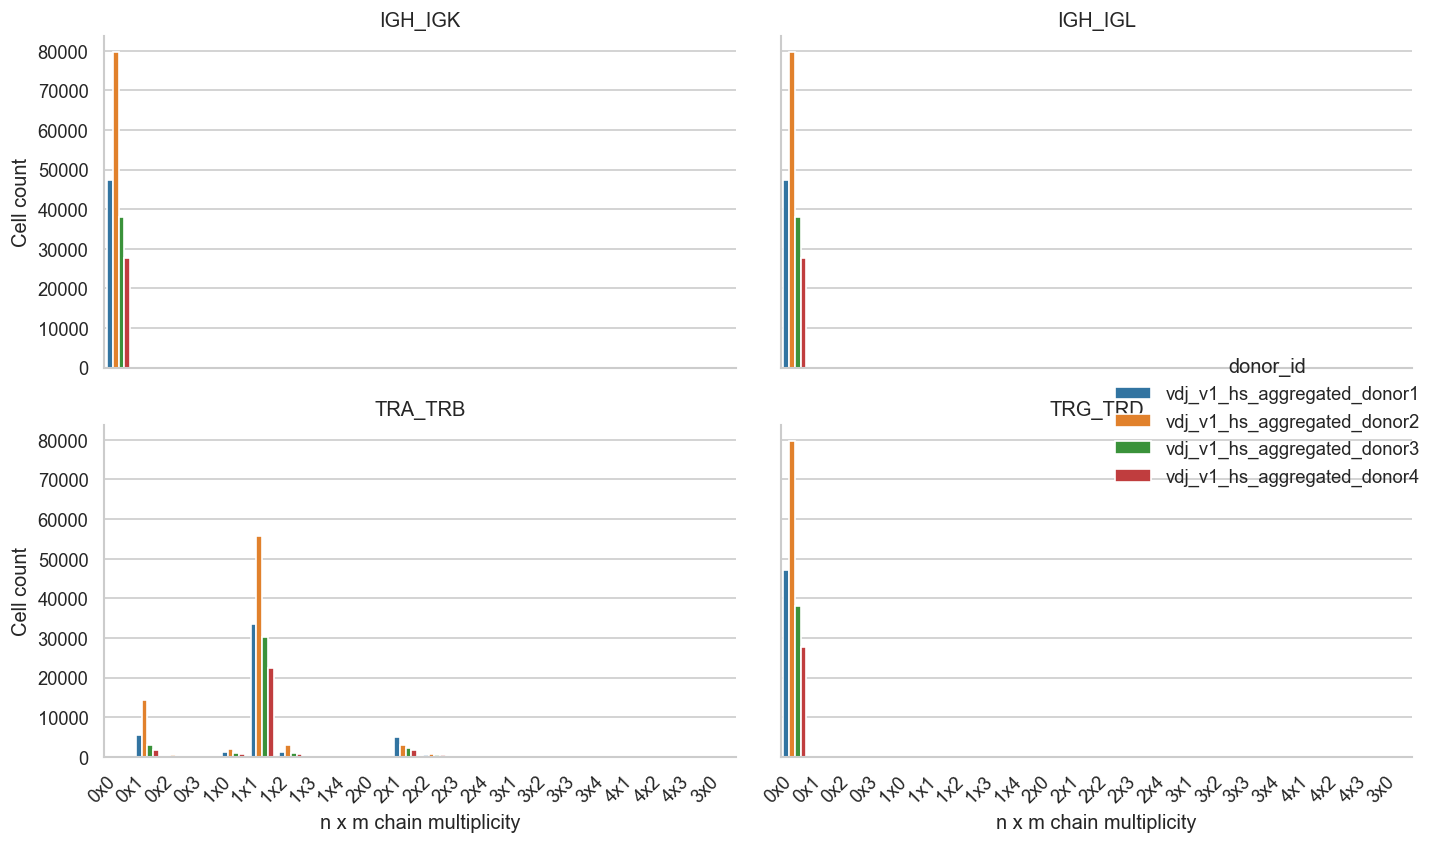

In [4]:
# Render barplots for n/m multiplicity across all locus pairs and donors.
plot_df = multiplicity.to_pandas().copy()
plot_df['nm'] = plot_df['n_chain1'].astype(str) + 'x' + plot_df['m_chain2'].astype(str)

fig = sns.catplot(
    data=plot_df,
    kind='bar',
    x='nm',
    y='cell_count',
    hue='donor_id',
    col='locus_pair',
    col_wrap=2,
    height=3.6,
    aspect=1.3,
    palette='tab10',
)
fig.set_axis_labels('n x m chain multiplicity', 'Cell count')
fig.set_titles('{col_name}')
for ax in fig.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

In [5]:
# Show compact donor summaries for common and edge n/m bins.
summary = (
    multiplicity
    .filter((pl.col('locus_pair') == 'TRA_TRB'))
    .sort(['donor_id', 'n_chain1', 'm_chain2'])
)
display(summary.to_pandas())

dominant = (
    multiplicity
    .sort('cell_count', descending=True)
    .group_by(['donor_id', 'locus_pair'])
    .head(3)
    .sort(['donor_id', 'locus_pair', 'cell_count'], descending=[False, False, True])
)
print('Top 3 bins by donor and locus_pair:')
display(dominant.to_pandas())

,donor_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
1,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,2,176
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,3,2
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,0,1222
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
...,...,...,...,...,...
67,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,1,28
68,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,2,52
69,vdj_v1_hs_aggregated_donor4,TRA_TRB,3,3,4
70,vdj_v1_hs_aggregated_donor4,TRA_TRB,4,2,1


Top 3 bins by donor and locus_pair:


,donor_id,locus_pair,n_chain1,m_chain2,cell_count
0,vdj_v1_hs_aggregated_donor1,IGH_IGK,0,0,47271
1,vdj_v1_hs_aggregated_donor1,IGH_IGL,0,0,47271
2,vdj_v1_hs_aggregated_donor1,TRA_TRB,1,1,33475
3,vdj_v1_hs_aggregated_donor1,TRA_TRB,0,1,5389
4,vdj_v1_hs_aggregated_donor1,TRA_TRB,2,1,4867
5,vdj_v1_hs_aggregated_donor1,TRG_TRD,0,0,47271
6,vdj_v1_hs_aggregated_donor2,IGH_IGK,0,0,79704
7,vdj_v1_hs_aggregated_donor2,IGH_IGL,0,0,79704
8,vdj_v1_hs_aggregated_donor2,TRA_TRB,1,1,55755
9,vdj_v1_hs_aggregated_donor2,TRA_TRB,0,1,14374


In [6]:
# Optional benchmark against scirpy: load timing and TRA/TRB presence quadrants parity.
scirpy_rows = []

try:
    import io
    import warnings
    import contextlib
    import logging
    import scirpy as ir
    import awkward as ak

    logging.getLogger('scirpy').setLevel(logging.ERROR)
    parity_tables = []

    for key, all_contig, _consensus in pairs:
        t0 = time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                adata = ir.io.read_10x_vdj(all_contig, filtered=False)
        dt = time.perf_counter() - t0
        scirpy_rows.append({'donor_id': key, 'loader': 'scirpy.read_10x_vdj', 'seconds': dt})

        airr = adata.obsm['airr']
        n_tra = ak.to_numpy(ak.sum(airr.locus == 'TRA', axis=1))
        n_trb = ak.to_numpy(ak.sum(airr.locus == 'TRB', axis=1))

        q_sc = (
            pl.DataFrame({'n_tra': n_tra, 'n_trb': n_trb})
            .with_columns(
                pl.when(pl.col('n_tra') > 0).then(pl.lit('TRA+')).otherwise(pl.lit('TRA-')).alias('tra'),
                pl.when(pl.col('n_trb') > 0).then(pl.lit('TRB+')).otherwise(pl.lit('TRB-')).alias('trb'),
            )
            .group_by(['tra', 'trb'])
            .len()
            .rename({'len': 'cells_scirpy'})
            .with_columns(pl.lit(key).alias('donor_id'))
        )

        q_mir = (
            donor_results[key].chain_multiplicity
            .filter(pl.col('locus_pair') == 'TRA_TRB')
            .with_columns(
                pl.when(pl.col('n_chain1') > 0).then(pl.lit('TRA+')).otherwise(pl.lit('TRA-')).alias('tra'),
                pl.when(pl.col('m_chain2') > 0).then(pl.lit('TRB+')).otherwise(pl.lit('TRB-')).alias('trb'),
            )
            .group_by(['tra', 'trb'])
            .agg(pl.sum('cell_count').alias('cells_mirpy'))
            .with_columns(pl.lit(key).alias('donor_id'))
        )

        parity = (
            q_mir.join(q_sc, on=['donor_id', 'tra', 'trb'], how='full')
            .with_columns(
                pl.coalesce([pl.col('donor_id'), pl.col('donor_id_right')]).alias('donor_id_merged'),
                pl.coalesce([pl.col('tra'), pl.col('tra_right')]).alias('tra_merged'),
                pl.coalesce([pl.col('trb'), pl.col('trb_right')]).alias('trb_merged'),
            )
            .with_columns(
                pl.col('cells_mirpy').cast(pl.Int64, strict=False).fill_null(0).alias('cells_mirpy'),
                pl.col('cells_scirpy').cast(pl.Int64, strict=False).fill_null(0).alias('cells_scirpy'),
            )
            .select([
                pl.col('donor_id_merged').alias('donor_id'),
                pl.col('tra_merged').alias('tra'),
                pl.col('trb_merged').alias('trb'),
                'cells_mirpy',
                'cells_scirpy',
            ])
            .with_columns((pl.col('cells_mirpy') - pl.col('cells_scirpy')).alias('delta'))
            .sort(['donor_id', 'tra', 'trb'])
        )
        parity_tables.append(parity)

    benchmark_df = pd.concat([pd.DataFrame(runtime_rows), pd.DataFrame(scirpy_rows)], ignore_index=True)
    display(benchmark_df.sort_values(['donor_id', 'loader']))

    parity_all = pl.concat(parity_tables)
    parity_summary = (
        parity_all.group_by('donor_id')
        .agg(
            pl.col('delta').abs().max().alias('max_abs_delta'),
            pl.when(pl.col('delta') == 0).then(1).otherwise(0).sum().alias('quadrants_equal')
        )
        .sort('donor_id')
    )
    print('Parity summary (expect 4 equal quadrants and max_abs_delta=0 for perfect match):')
    display(parity_summary.to_pandas())

except Exception as exc:
    print('Scirpy benchmark skipped or failed:', repr(exc))

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


,donor_id,loader,seconds
0,vdj_v1_hs_aggregated_donor1,mirpy,0.755649
4,vdj_v1_hs_aggregated_donor1,scirpy.read_10x_vdj,9.625174
1,vdj_v1_hs_aggregated_donor2,mirpy,1.182035
5,vdj_v1_hs_aggregated_donor2,scirpy.read_10x_vdj,14.899633
2,vdj_v1_hs_aggregated_donor3,mirpy,0.992187
6,vdj_v1_hs_aggregated_donor3,scirpy.read_10x_vdj,24.932215
3,vdj_v1_hs_aggregated_donor4,mirpy,0.770204
7,vdj_v1_hs_aggregated_donor4,scirpy.read_10x_vdj,17.925495


Parity summary (expect 4 equal quadrants and max_abs_delta=0 for perfect match):


,donor_id,max_abs_delta,quadrants_equal
0,vdj_v1_hs_aggregated_donor1,6694,0
1,vdj_v1_hs_aggregated_donor2,10711,0
2,vdj_v1_hs_aggregated_donor3,138089,0
3,vdj_v1_hs_aggregated_donor4,93574,0


## Suggested parity test against scirpy

A robust parity target is to compare **presence quadrants** for TRA/TRB per cell (`TRA+/TRB+`, `TRA+/TRB-`, `TRA-/TRB+`, `TRA-/TRB-`) between:

1. `mirpy` (`load_10x_vdj_v1_donor`) using `chain_multiplicity` collapsed to presence/absence.
2. `scirpy` (`ir.io.read_10x_vdj(..., filtered=False)`) using `obsm['airr']` locus counts per cell.

This directly verifies consistent handling of absent chains/orphan-chain cells while remaining stable across differences in chain indexing internals.